# Portfolio Optimization Equity Demo

This notebook extends the portfolio-optimization prototype to real equity return series using downloaded market data.

It is a smaller follow-on experiment to the synthetic portfolio notebook.


In [408]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import cvxopt as opt
from cvxopt import blas, solvers

In [700]:
tickers = ['SOFI', 'HOOD', 'AFRM', 'PYPL']
df = yf.download(tickers, start = '2022-01-01', end = '2025-02-20')
data = df.Close.copy()

[*********************100%***********************]  4 of 4 completed


In [702]:
data1 =np.log(data.pct_change()+1).dropna()

In [742]:
data1 =np.array(data1)

In [744]:
data = np.asmatrix(data1)

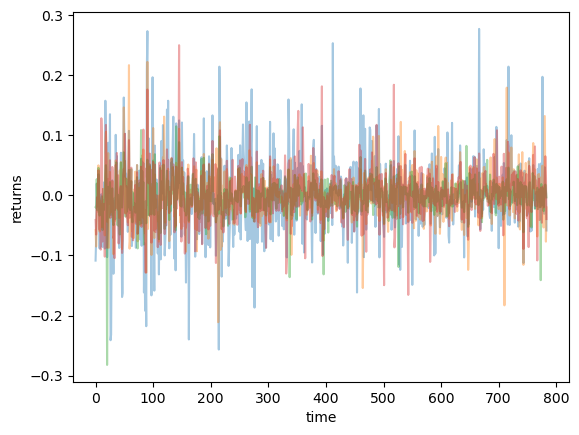

In [748]:
plt.plot(data1, alpha=.4);
plt.xlabel('time')
plt.ylabel('returns');

In [750]:
def rand_weights(n):
    ''' Produces n random weights that sum to 1 '''
    k = np.random.rand(n)
    return k / sum(k)

In [756]:
def portfolio(returns):
    ''' 
    Returns the mean and standard deviation of returns for a portfolio
    '''
    p = np.asmatrix(np.mean(returns, axis=1))
    w = np.asmatrix(rand_weights(returns.shape[0]))
    C = np.asmatrix(np.cov(returns))
        
    mu = w * p.T
    sigma = np.sqrt(w * C * w.T)
    
    # This recursion reduces outliers to keep plots pretty
    # if sigma > 2:
    #     return portfolio(returns)
    return mu, sigma

In [758]:
n_portfolios = 1000
means, stds = np.column_stack([
    portfolio(data1)
    for _ in range(n_portfolios)  # Changed xrange to range
])*100

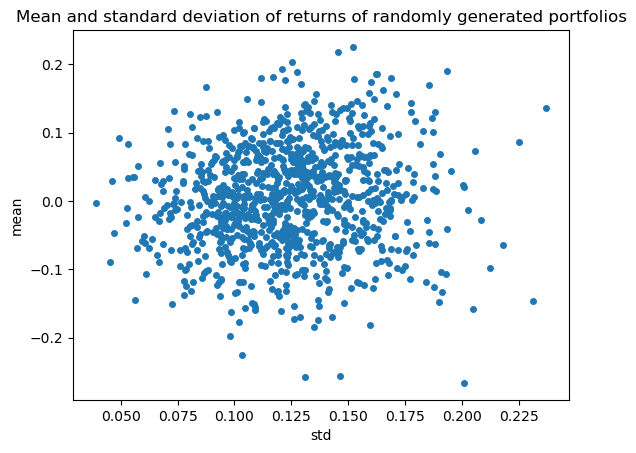

In [759]:
plt.plot( stds,means, 'o', markersize=4)
plt.xlabel('std')
plt.ylabel('mean')
plt.title('Mean and standard deviation of returns of randomly generated portfolios');

In [766]:
def optimal_portfolio(returns):
    n = len(returns)
    returns = np.asmatrix(returns)
    # The `mus` vector produces a non-linear series of expected return values mu
    # for each of which we will find a minimum-variance portfolio. We will see later that we don‘t need to calculate a lot of these, 
    # as they perfectly fit a parabola which can safely be extrapolated for higher values.
    N = 100
    mus = [10**(5.0 * t/N - 1.0) for t in range(N)]
    
    # Convert to cvxopt matrices
    S = opt.matrix(np.cov(returns))
    pbar = opt.matrix(np.mean(returns, axis=1))
    
    # Create constraint matrices
    G = -opt.matrix(np.eye(n))   # negative n x n identity matrix
    h = opt.matrix(0.0, (n ,1))
    A = opt.matrix(1.0, (1, n))
    b = opt.matrix(1.0)
    
    # Calculate efficient frontier weights using quadratic programming
    portfolios = [solvers.qp(mu*S, -pbar, G, h, A, b)['x'] 
                  for mu in mus]
    ## CALCULATE RISKS AND RETURNS FOR FRONTIER
    returns = [blas.dot(pbar, x) for x in portfolios]
    risks = [np.sqrt(blas.dot(x, S*x)) for x in portfolios]
    ## CALCULATE THE 2ND DEGREE POLYNOMIAL OF THE FRONTIER CURVE
    m1 = np.polyfit(returns, risks, 2)
    x1 = np.sqrt(m1[2] / m1[0])
    # CALCULATE THE OPTIMAL PORTFOLIO
    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']
    return np.asarray(wt), returns, risks

weights, returns, risks = optimal_portfolio(data1)

plt.plot(stds, means, 'o')
plt.ylabel('mean')
plt.xlabel('std')
plt.plot(risks, returns, 'y-o');

     pcost       dcost       gap    pres   dres
 0: -1.0177e+00 -1.1882e+00  1e+03  3e+01  3e+01
 1: -1.2338e-02 -1.1767e+00  1e+01  3e-01  3e-01
 2: -2.6546e-03 -9.3295e-01  9e-01  4e-16  6e-15
 3: -5.0659e-03 -1.9022e-01  2e-01  3e-16  1e-14
 4: -1.7284e-01 -3.4026e-01  2e-01  4e-16  3e-15
 5: -1.7944e-01 -1.8390e-01  4e-03  8e-16  5e-15
 6: -1.8229e-01 -1.8234e-01  5e-05  4e-16  3e-15
 7: -1.8232e-01 -1.8232e-01  5e-07  4e-16  3e-15
 8: -1.8232e-01 -1.8232e-01  5e-09  3e-16  3e-15
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.0145e+00 -1.1888e+00  1e+03  3e+01  3e+01
 1: -1.2507e-02 -1.1763e+00  1e+01  3e-01  3e-01
 2: -2.6697e-03 -9.3329e-01  9e-01  1e-15  6e-15
 3: -5.0807e-03 -1.9022e-01  2e-01  9e-18  1e-14
 4: -1.7246e-01 -3.3999e-01  2e-01  1e-15  3e-15
 5: -1.7931e-01 -1.8385e-01  5e-03  2e-15  5e-15
 6: -1.8224e-01 -1.8229e-01  5e-05  2e-15  3e-15
 7: -1.8227e-01 -1.8227e-01  5e-07  4e-16  3e-15
 8: -1.8227e-01 -1.8227e-01  5e-09  4e-16  3e-1

C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_676\601979587.py:28: RuntimeWarning: invalid value encountered in sqrt
  x1 = np.sqrt(m1[2] / m1[0])


ValueError: domain error

In [773]:
len(data1)

784